In [1]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
import os

import mne
import numpy as np
import pandas as pd
import scipy.stats
import matplotlib.pyplot as plt
import tqdm

mne.set_log_level('ERROR')

In [3]:
BANDS = [
    (0.9, 4,  'Delta'),
    (4,   8,  'Theta'),
    (8,   14, 'Alpha'),
    (12,  15, 'Sigma'),
    (14,  25, 'Beta'),
]
BAND_NAMES = [name for _, _, name in BANDS]

SLEEP_STAGE_NAMES = {1: 'Wake', 2: 'N1', 3: 'N2', 4: 'N3', 5: 'REM'}
SLEEP_EVENT_ID = {
    'Sleep stage W': 1,
    'Sleep stage 1': 2,
    'Sleep stage 2': 3,
    'Sleep stage 3': 4,
    'Sleep stage 4': 4,
    'Sleep stage R': 5,
}

def compute_band_powers_db(data, sfreq):
    """Returns mean log band power per epoch, averaged over channels.
    data: (n_epochs, n_channels, n_times)
    Returns: (n_epochs, n_bands)
    """
    psd, freqs = mne.time_frequency.psd_array_multitaper(
        data, sfreq=sfreq, fmin=BANDS[0][0], fmax=BANDS[-1][1],
        adaptive=True, n_jobs=-1, verbose='error'
    )
    band_powers = np.stack([
        psd[:, :, (freqs >= fmin) & (freqs < fmax)].mean(axis=-1)
        for fmin, fmax, _ in BANDS
    ], axis=-1)  # (n_epochs, n_channels, n_bands)
    db = 10 * np.log10(band_powers.mean(axis=1))  # average over channels, then dB
    return db  # (n_epochs, n_bands)

def epoch_stage_assignments(edges, n_epochs):
    """Map each epoch index to its TDA-detected stage index."""
    labels = np.zeros(n_epochs, dtype=int)
    edges = np.clip(edges, 0, n_epochs)
    for i, (start, end) in enumerate(zip(edges[:-1], edges[1:])):
        labels[start:end] = i
    return labels

## Part 1: Sleep-EDF — spectral fingerprint of TDA-detected stages

For each subject we load epoch data, assign each epoch a TDA-detected stage label and an
expert sleep stage label, then compute mean band powers per TDA stage.  If TDA boundaries
are physiologically meaningful, stages dominated by expert-labelled Wake epochs should show
high alpha power; N3-dominated stages should show high delta; N2-dominated stages should
show high sigma (spindle); and so on.

In [4]:
SLEEP_ROOT = 'E:/CourseProject/sleep-edf'
EPOCH_SEC  = 15.0
N_SUBJECTS = 153

sleep_stage_profiles = []   # list of {'expert_label', 'bp_z': (n_bands,)}
bp_z_by_subj   = {}         # subj_id -> (n_epochs, n_bands) — for silhouette / permutation tests
edges_by_subj  = {}         # subj_id -> {'tda': edges, 'trad': edges}

for i in tqdm.trange(N_SUBJECTS, desc='Sleep-EDF'):
    subj = f'{SLEEP_ROOT}/Subj{i}'
    tda_edges_path  = f'{subj}/exp_reduced_flow/results/topological/best_edges.txt'
    trad_edges_path = f'{subj}/exp_reduced_flow/results/traditional/best_edges.txt'
    eeg_path        = f'{subj}/eeg.edf'
    annot_path      = f'{subj}/annotations.edf'
    if not all(os.path.exists(p) for p in [tda_edges_path, eeg_path, annot_path]):
        continue

    try:
        annot = mne.read_annotations(annot_path)
        annot.crop(annot[1]['onset'] - 15 * 60, annot[-2]['onset'] + 15 * 60)
        raw = mne.io.read_raw_edf(eeg_path, preload=True, infer_types=True, verbose='error')
        raw.set_annotations(annot, verbose='error')
        events, _ = mne.events_from_annotations(
            raw, event_id=SLEEP_EVENT_ID, chunk_duration=EPOCH_SEC, verbose='error'
        )
        tmax   = EPOCH_SEC - 1.0 / raw.info['sfreq']
        epochs = mne.Epochs(raw=raw, events=events, tmin=0.0, tmax=tmax,
                            baseline=None, preload=True, verbose='error')

        eeg_picks = mne.pick_types(epochs.info, eeg=True)
        data      = epochs.get_data(picks=eeg_picks)
        n_epochs  = len(data)
        expert_labels = events[:n_epochs, 2]

        bp_db = compute_band_powers_db(data, raw.info['sfreq'])
        bp_z  = (bp_db - bp_db.mean(axis=0)) / (bp_db.std(axis=0) + 1e-9)

        tda_edges = np.loadtxt(tda_edges_path).astype(int)
        tda_stage = epoch_stage_assignments(tda_edges, n_epochs)

        for stage_idx in range(len(tda_edges) - 1):
            mask = tda_stage == stage_idx
            if mask.sum() < 3:
                continue
            dominant_label = int(scipy.stats.mode(expert_labels[mask], keepdims=True).mode[0])
            sleep_stage_profiles.append({
                'expert_label': dominant_label,
                'bp_z': bp_z[mask].mean(axis=0),
            })

        # Cache for downstream analyses
        bp_z_by_subj[i] = bp_z
        edict = {'tda': tda_edges}
        if os.path.exists(trad_edges_path):
            edict['trad'] = np.loadtxt(trad_edges_path).astype(int)
        edges_by_subj[i] = edict

    except Exception as e:
        print(f'Subj{i}: {e}')

print(f'Collected {len(sleep_stage_profiles)} stage profiles from {N_SUBJECTS} subjects')
print(f'Subjects with traditional edges: {sum(1 for e in edges_by_subj.values() if "trad" in e)}')


Sleep-EDF: 100%|██████████| 153/153 [19:03<00:00,  7.48s/it]

Collected 1659 stage profiles from 153 subjects
Subjects with traditional edges: 153


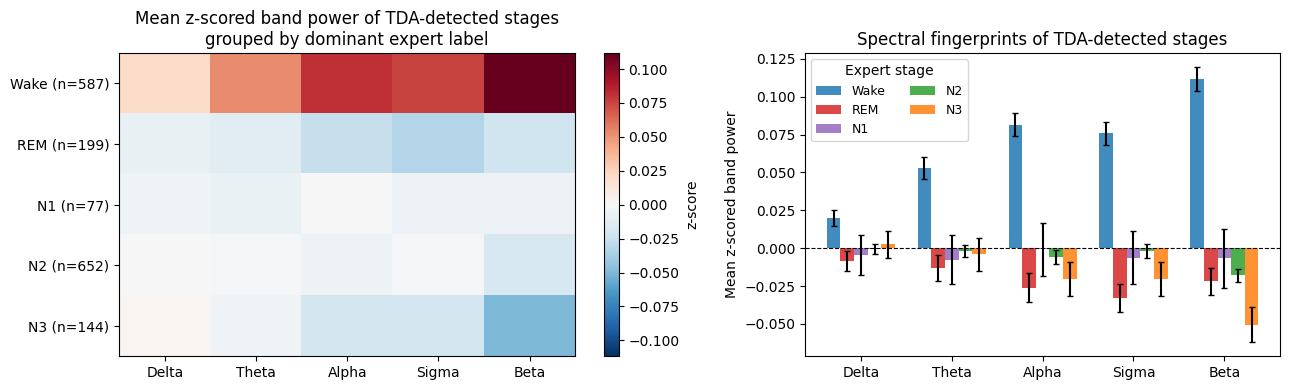

In [5]:
# Build mean spectral profile per expert-labelled stage group
STAGE_ORDER = [1, 5, 2, 3, 4]  # Wake, REM, N1, N2, N3

group_means = {}
group_sems  = {}
group_ns    = {}
for stage_num in STAGE_ORDER:
    profiles = np.stack([p['bp_z'] for p in sleep_stage_profiles
                         if p['expert_label'] == stage_num])
    group_means[stage_num] = profiles.mean(axis=0)
    group_sems[stage_num]  = profiles.std(axis=0) / np.sqrt(len(profiles))
    group_ns[stage_num]    = len(profiles)

# Heatmap: rows = expert stage groups, columns = frequency bands
heatmap = np.stack([group_means[s] for s in STAGE_ORDER])

fig, axes = plt.subplots(1, 2, figsize=(13, 4), gridspec_kw={'width_ratios': [1.2, 1]})

# -- heatmap --
ax = axes[0]
im = ax.imshow(heatmap, aspect='auto', cmap='RdBu_r',
               vmin=-np.abs(heatmap).max(), vmax=np.abs(heatmap).max())
ax.set_xticks(range(len(BAND_NAMES)))
ax.set_xticklabels(BAND_NAMES)
ax.set_yticks(range(len(STAGE_ORDER)))
ax.set_yticklabels([f"{SLEEP_STAGE_NAMES[s]} (n={group_ns[s]})" for s in STAGE_ORDER])
ax.set_title('Mean z-scored band power of TDA-detected stages\ngrouped by dominant expert label')
plt.colorbar(im, ax=ax, label='z-score')

# -- bar chart with error bars --
ax2 = axes[1]
colors = ['C0', 'C3', 'C4', 'C2', 'C1']
x = np.arange(len(BAND_NAMES))
width = 0.15
for offset, (stage_num, color) in enumerate(zip(STAGE_ORDER, colors)):
    ax2.bar(x + offset * width, group_means[stage_num], width=width,
            yerr=group_sems[stage_num], capsize=2,
            label=SLEEP_STAGE_NAMES[stage_num], color=color, alpha=0.85)
ax2.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax2.set_xticks(x + 2 * width)
ax2.set_xticklabels(BAND_NAMES)
ax2.set_ylabel('Mean z-scored band power')
ax2.set_title('Spectral fingerprints of TDA-detected stages')
ax2.legend(title='Expert stage', fontsize=9, ncol=2)

fig.tight_layout()
fig.savefig('spectral_validation_sleep.svg')
plt.show()

Kruskal-Wallis: z-scored band power differs across expert-label groups
Band             H       p-value  sig
Delta         22.5      1.61e-04  ***
Theta         55.2      2.95e-11  ***
Alpha        119.4      7.15e-25  ***
Sigma        103.9      1.46e-21  ***
Beta         235.1      1.05e-49  ***

Spectral silhouette comparison (153 subjects with both edge files)
TDA:         -0.0992 ± 0.0307
Traditional: -0.0849 ± 0.0245
TDA > Trad:  35.3% of subjects
Wilcoxon signed-rank (TDA > Trad): W=3255, p=1.00e+00


C:\Users\TTPO100AJIEX\AppData\Local\Temp\ipykernel_24332\2983918505.py:62: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([df_sil['trad'], df_sil['tda']], labels=['Traditional', 'TDA'])


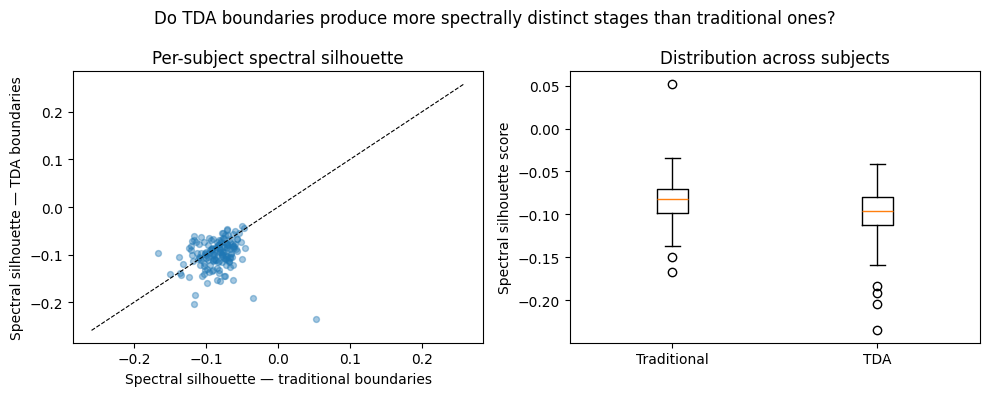

In [15]:
## Part 1b: Statistical tests — Kruskal-Wallis across expert-label groups
from scipy.stats import kruskal, wilcoxon
from sklearn.metrics import silhouette_score

print('Kruskal-Wallis: z-scored band power differs across expert-label groups')
print(f'{"Band":<8}  {"H":>8}  {"p-value":>12}  sig')
for band_idx, band_name in enumerate(BAND_NAMES):
    groups = [
        [p['bp_z'][band_idx] for p in sleep_stage_profiles if p['expert_label'] == s]
        for s in STAGE_ORDER
    ]
    stat, pval = kruskal(*[g for g in groups if g])
    stars = '***' if pval < 0.001 else ('**' if pval < 0.01 else ('*' if pval < 0.05 else 'ns'))
    print(f'{band_name:<8}  {stat:>8.1f}  {pval:>12.2e}  {stars}')

## Part 1c: Spectral silhouette — TDA vs traditional boundaries
# For each subject, compute the silhouette score of stage labels (from each edge set)
# using band powers as features.  A higher value means stages are more spectrally distinct.

def spectral_sil(edges, bp_z):
    labels = epoch_stage_assignments(edges, len(bp_z))
    n_unique = len(np.unique(labels))
    if n_unique < 2:
        return np.nan
    try:
        return silhouette_score(bp_z, labels)
    except Exception:
        return np.nan

rows = []
for subj_id, edict in edges_by_subj.items():
    if 'trad' not in edict:
        continue
    bz = bp_z_by_subj.get(subj_id)
    if bz is None:
        continue
    rows.append({
        'tda':  spectral_sil(edict['tda'],  bz),
        'trad': spectral_sil(edict['trad'], bz),
    })

df_sil = pd.DataFrame(rows).dropna()
print(f'\nSpectral silhouette comparison ({len(df_sil)} subjects with both edge files)')
print(f'TDA:         {df_sil["tda"].mean():.4f} ± {df_sil["tda"].std():.4f}')
print(f'Traditional: {df_sil["trad"].mean():.4f} ± {df_sil["trad"].std():.4f}')
print(f'TDA > Trad:  {(df_sil["tda"] > df_sil["trad"]).mean():.1%} of subjects')
if len(df_sil) > 1:
    stat, pval = wilcoxon(df_sil['tda'], df_sil['trad'], alternative='greater')
    print(f'Wilcoxon signed-rank (TDA > Trad): W={stat:.0f}, p={pval:.2e}')

if len(df_sil) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    ax = axes[0]
    ax.scatter(df_sil['trad'], df_sil['tda'], alpha=0.4, s=18)
    lim = max(df_sil[['tda', 'trad']].abs().max()) * 1.1
    ax.plot([-lim, lim], [-lim, lim], 'k--', lw=0.8)
    ax.set_xlabel('Spectral silhouette — traditional boundaries')
    ax.set_ylabel('Spectral silhouette — TDA boundaries')
    ax.set_title('Per-subject spectral silhouette')

    axes[1].boxplot([df_sil['trad'], df_sil['tda']], labels=['Traditional', 'TDA'])
    axes[1].set_ylabel('Spectral silhouette score')
    axes[1].set_title('Distribution across subjects')

    fig.suptitle('Do TDA boundaries produce more spectrally distinct stages than traditional ones?')
    fig.tight_layout()
    fig.savefig('spectral_silhouette_sleep.svg')
    plt.show()


## Part 2: Meditation — spectral profiles across TDA-detected stages (all bands, all regions)

For subjects 1–3 we compute band power across all five frequency bands (Delta, Theta, Alpha,
Sigma, Beta) for each of the 11 brain regions defined in the paper.  We then plot heatmaps
of mean z-scored power per TDA-detected stage, run Kruskal-Wallis tests to assess whether
band power differs significantly across stages, and apply a permutation test to check whether
TDA boundaries are more spectrally informative than random boundaries of the same count.
We also compare spectral silhouette scores for TDA vs traditional boundaries.

In [4]:
MEDITATION_SUBJS = [1, 2, 3]

# 11 regions from the paper (approximate 10-20 channel membership)
REGION_MAP = {
    'FP':  ['Fp1', 'Fpz', 'Fp2'],
    'LF':  ['AF1', 'F7',  'F3',  'FT7', 'FC3'],
    'MF':  ['AFz', 'Fz',  'FCz'],
    'RF':  ['AF2', 'F4',  'F8',  'FC4', 'FT8'],
    'LC':  ['C3',  'CP3'],
    'MC':  ['Cz',  'CPz'],
    'RC':  ['C4',  'CP4'],
    'LT':  ['T7',  'TP7'],
    'RT':  ['T8',  'TP8'],
    'PAR': ['P7',  'P3',  'Pz',  'P4',  'P8'],
    'OCC': ['O1',  'Oz',  'O2'],
}

meditation_full = {}

for subj_num in MEDITATION_SUBJS:
    subj = f'E:/CourseProject/Subj{subj_num}'
    tda_edges_path  = f'{subj}/exp_full_flow/results/best_topological/best_edges.txt'
    trad_edges_path = f'{subj}/exp_full_flow/results/traditional/best_edges.txt'
    epo_path        = f'{subj}/src/epochs_filt_rr-epo.fif'

    if not all(os.path.exists(p) for p in [tda_edges_path, epo_path]):
        print(f'Subject {subj_num}: required files not found, skipping')
        continue

    epochs = mne.read_epochs(epo_path, verbose='error').drop_channels(['A1', 'A2'], on_missing='ignore')
    if subj_num == 2:
        epochs = epochs[:-2]

    data     = epochs.get_data()
    n_epochs = len(data)
    sfreq    = epochs.info['sfreq']
    ch_names = epochs.ch_names

    psd, freqs = mne.time_frequency.psd_array_multitaper(
        data, sfreq=sfreq, fmin=BANDS[0][0], fmax=BANDS[-1][1],
        adaptive=True, n_jobs=-1, verbose='error'
    )
    bp = np.stack([
        psd[:, :, (freqs >= fmin) & (freqs < fmax)].mean(axis=-1)
        for fmin, fmax, _ in BANDS
    ], axis=-1)  # (n_epochs, n_ch, n_bands)

    bp_z = (bp - bp.mean(axis=0, keepdims=True)) / (bp.std(axis=0, keepdims=True) + 1e-9)

    tda_edges = np.loadtxt(tda_edges_path).astype(int)
    tda_stage = epoch_stage_assignments(tda_edges, n_epochs)
    n_stages  = len(tda_edges) - 1

    global_profiles = np.array([
        bp_z[tda_stage == s].mean(axis=(0, 1)) for s in range(n_stages)
    ])

    region_profiles = {}
    for region, region_chs in REGION_MAP.items():
        idx = [j for j, ch in enumerate(ch_names) if ch in region_chs]
        if idx:
            region_profiles[region] = np.array([
                bp_z[tda_stage == s][:, idx, :].mean(axis=(0, 1)) for s in range(n_stages)
            ])

    trad_edges = np.loadtxt(trad_edges_path).astype(int) if os.path.exists(trad_edges_path) else None

    meditation_full[subj_num] = {
        'global_profiles': global_profiles,
        'region_profiles': region_profiles,
        'bp_z':       bp_z,
        'bp_mean':    bp_z.mean(axis=1),   # (n_epochs, n_bands)
        'tda_stage':  tda_stage,
        'tda_edges':  tda_edges,
        'trad_edges': trad_edges,
        'n_stages':   n_stages,
        'n_epochs':   n_epochs,
        'ch_names':   ch_names,
    }
    trad_str = 'yes' if trad_edges is not None else 'not found'
    print(f'Subject {subj_num}: {n_stages} stages, {len(ch_names)} channels, '
          f'{len(region_profiles)} regions, traditional edges: {trad_str}')


Subject 1: 9 stages, 38 channels, 11 regions, traditional edges: yes
Subject 2: 8 stages, 38 channels, 11 regions, traditional edges: yes
Subject 3: 10 stages, 38 channels, 11 regions, traditional edges: yes


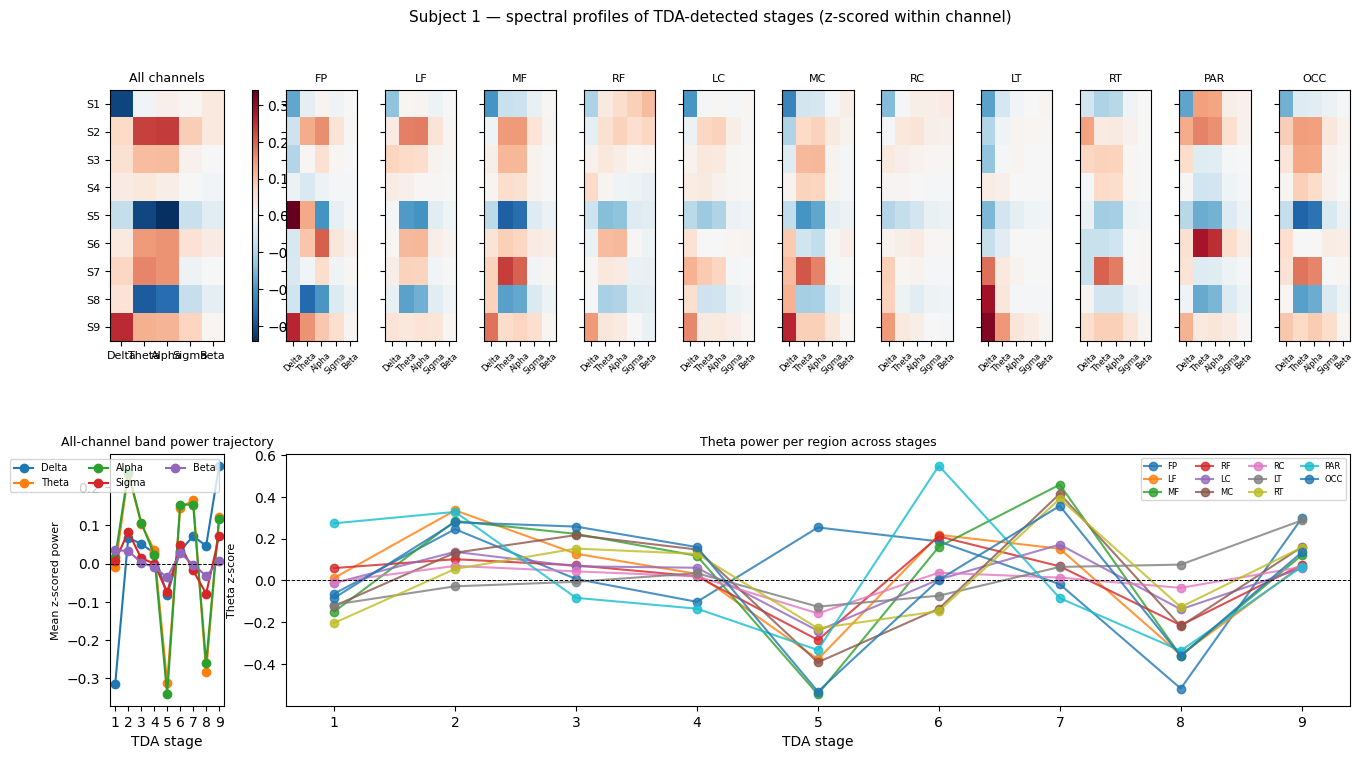

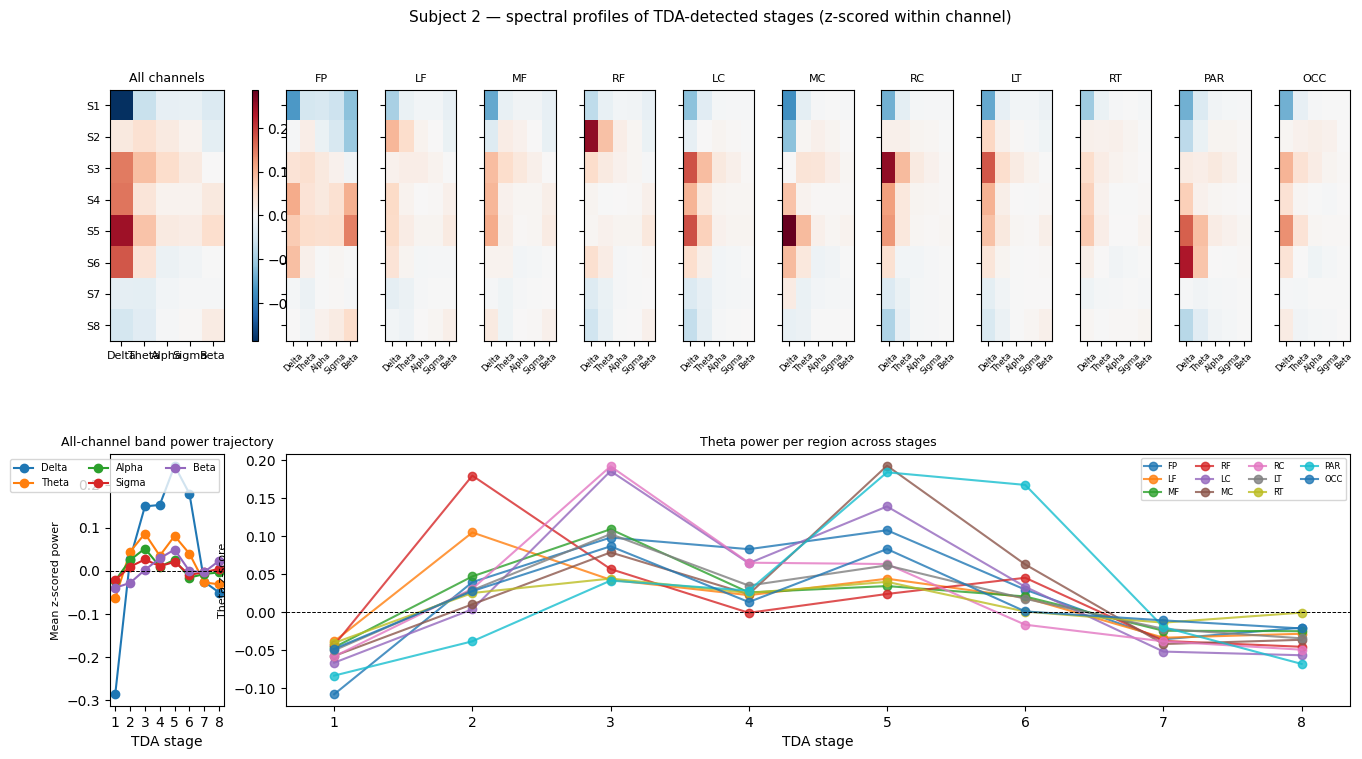

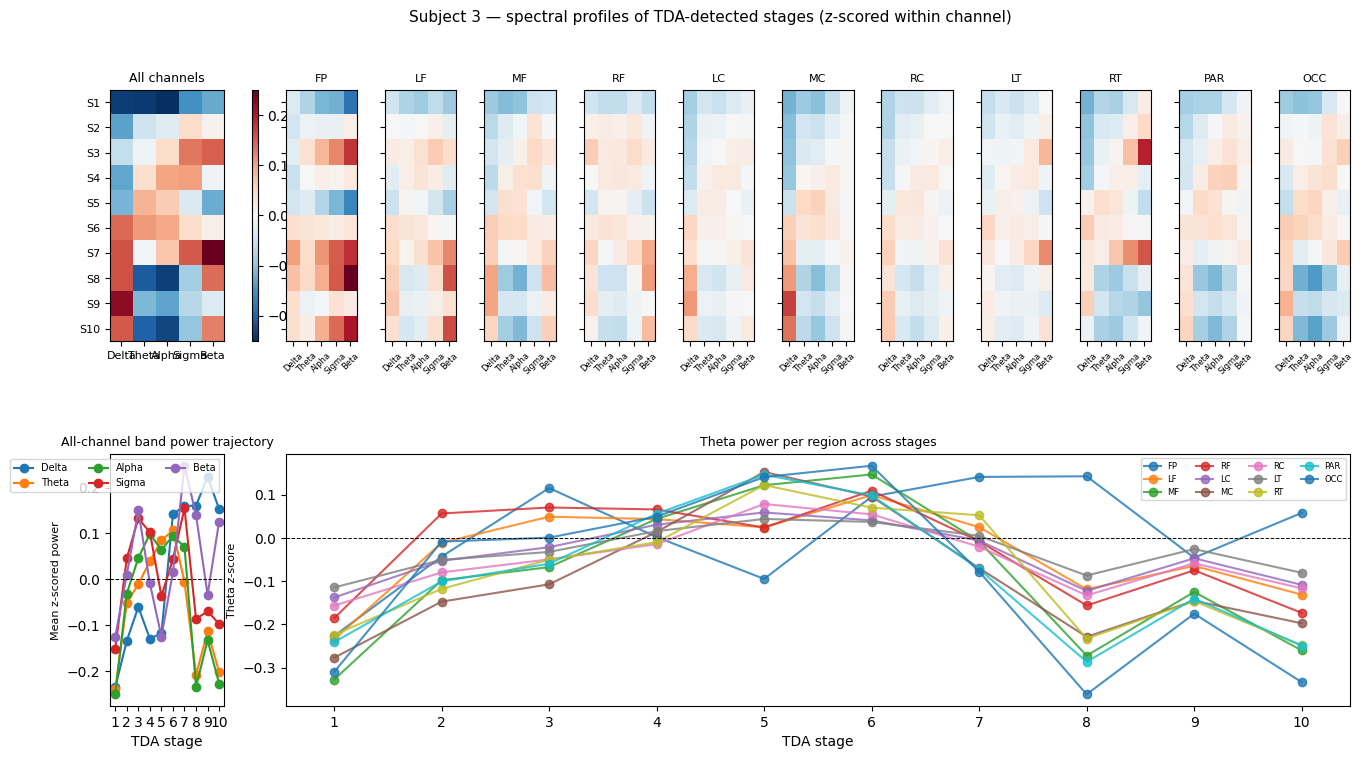

In [5]:
## Part 2a: Heatmaps — all bands × all stages, and regional breakdown

for subj_num, res in meditation_full.items():
    profiles = res['global_profiles']   # (n_stages, n_bands)
    n_stages = res['n_stages']
    reg_prof = res['region_profiles']
    regions  = list(reg_prof.keys())
    vmax_g   = np.abs(profiles).max()
    vmax_r   = max(np.abs(v).max() for v in reg_prof.values()) if reg_prof else 1

    fig = plt.figure(figsize=(16, 8))
    gs  = fig.add_gridspec(2, len(regions) + 2, hspace=0.45, wspace=0.4,
                           width_ratios=[1.6, 0.08] + [1] * len(regions))

    # --- Global heatmap (stages × bands) ---
    ax_g = fig.add_subplot(gs[0, 0])
    im_g = ax_g.imshow(profiles, aspect='auto', cmap='RdBu_r', vmin=-vmax_g, vmax=vmax_g)
    ax_g.set_xticks(range(len(BAND_NAMES))); ax_g.set_xticklabels(BAND_NAMES, fontsize=8)
    ax_g.set_yticks(range(n_stages)); ax_g.set_yticklabels([f'S{s+1}' for s in range(n_stages)], fontsize=8)
    ax_g.set_title('All channels', fontsize=9)
    fig.colorbar(im_g, cax=fig.add_subplot(gs[0, 1]), label='z-score')

    # --- Per-region heatmaps ---
    for col, region in enumerate(regions):
        ax_r = fig.add_subplot(gs[0, col + 2])
        rp = reg_prof[region]   # (n_stages, n_bands)
        ax_r.imshow(rp, aspect='auto', cmap='RdBu_r', vmin=-vmax_r, vmax=vmax_r)
        ax_r.set_xticks(range(len(BAND_NAMES))); ax_r.set_xticklabels(BAND_NAMES, fontsize=6, rotation=45)
        ax_r.set_yticks(range(n_stages)); ax_r.set_yticklabels([])
        ax_r.set_title(region, fontsize=8)

    # --- Line plot: all bands across stages (global) ---
    ax_l = fig.add_subplot(gs[1, 0])
    x = np.arange(1, n_stages + 1)
    for band_idx, band_name in enumerate(BAND_NAMES):
        ax_l.plot(x, profiles[:, band_idx], 'o-', label=band_name)
    ax_l.axhline(0, color='k', lw=0.7, ls='--')
    ax_l.set_xlabel('TDA stage'); ax_l.set_ylabel('Mean z-scored power', fontsize=8)
    ax_l.set_xticks(x); ax_l.legend(fontsize=7, ncol=3, loc='best')
    ax_l.set_title('All-channel band power trajectory', fontsize=9)

    # --- Line plot per region for a selected band (theta, most physiologically relevant) ---
    theta_idx = BAND_NAMES.index('Theta')
    ax_reg = fig.add_subplot(gs[1, 2:])
    for region in regions:
        if region in reg_prof:
            ax_reg.plot(x, reg_prof[region][:, theta_idx], 'o-', label=region, alpha=0.8)
    ax_reg.axhline(0, color='k', lw=0.7, ls='--')
    ax_reg.set_xlabel('TDA stage'); ax_reg.set_ylabel('Theta z-score', fontsize=8)
    ax_reg.set_xticks(x); ax_reg.legend(fontsize=6, ncol=4, loc='best')
    ax_reg.set_title('Theta power per region across stages', fontsize=9)

    fig.suptitle(f'Subject {subj_num} — spectral profiles of TDA-detected stages '
                 f'(z-scored within channel)', fontsize=11)
    fig.savefig(f'meditation_spectral_subj{subj_num}.svg')
    plt.show()


Subj   Method           Delta    Theta    Alpha    Sigma     Beta  Pairwise sig.
--------------------------------------------------------------------------------
1      TDA              117.8    438.7    462.5    430.3    588.0  27/40 (68%)
1      Traditional      172.0    426.3    440.2    393.1    529.6  29/40 (72%)

2      TDA              804.5    602.1    131.8    126.0    704.9  19/35 (54%)
2      Traditional      806.1    607.0    160.4    157.6    697.4  22/35 (63%)

3      TDA              182.3    183.6    123.4     89.2    689.6  14/45 (31%)
3      Traditional      247.8    183.3    111.8     66.7    607.8  16/45 (36%)


LaTeX rows (copy into table2):
  1 & TDA           & 117.8 & 438.7 & 462.5 & 430.3 & 588.0 & 27/40 (68\%) \\
  1 & Traditional   & 172.0 & 426.3 & 440.2 & 393.1 & 529.6 & 29/40 (72\%) \\
  2 & TDA           & 804.5 & 602.1 & 131.8 & 126.0 & 704.9 & 19/35 (54\%) \\
  2 & Traditional   & 806.1 & 607.0 & 160.4 & 157.6 & 697.4 & 22/35 (63\%) \\
  3 & TDA        

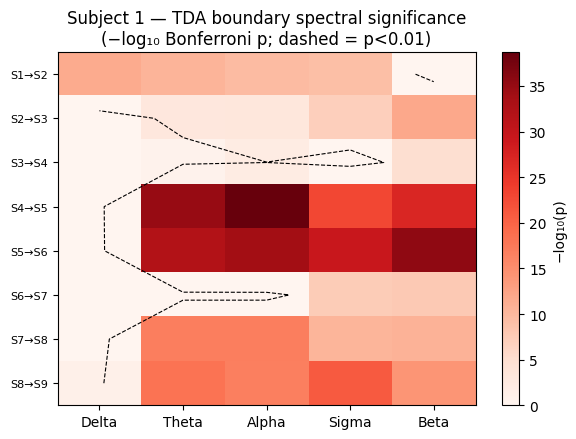


Subject 2:
  S1→S2: Delta, Theta, Alpha, Sigma, Beta
  S2→S3: Delta, Beta
  S3→S4: Theta, Beta
  S4→S5: Delta, Theta, Beta
  S5→S6: Theta, Alpha, Sigma, Beta
  S6→S7: Delta, Theta
  S7→S8: Beta


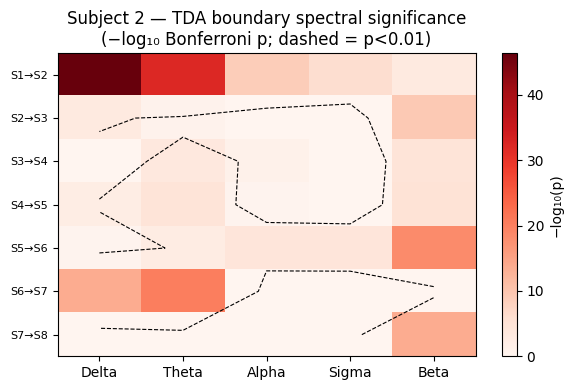


Subject 3:
  S1→S2: Theta, Beta
  S2→S3: Beta
  S3→S4: Beta
  S4→S5: Beta
  S5→S6: Delta, Beta
  S6→S7: Beta
  S7→S8: Theta, Alpha, Sigma, Beta
  S8→S9: Beta
  S9→S10: Beta


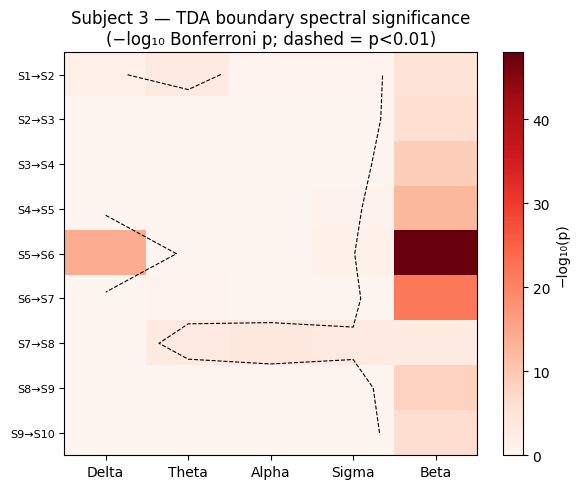

In [6]:
from scipy.stats import kruskal, mannwhitneyu
from sklearn.metrics import silhouette_score

def kw_hstats(bp_mean, stage_labels):
    """Kruskal-Wallis H per band; returns list of (H, p)."""
    stages = np.unique(stage_labels)
    out = []
    for band_idx in range(bp_mean.shape[1]):
        groups = [bp_mean[stage_labels == s, band_idx]
                  for s in stages if (stage_labels == s).sum() > 1]
        if len(groups) < 2:
            out.append((np.nan, np.nan))
        else:
            out.append(kruskal(*groups))
    return out

def pairwise_sig(bp_mean, stage_labels):
    """Adjacent-stage Mann-Whitney U (Bonferroni). Returns (n_sig, n_total, sig_matrix)."""
    stages  = sorted(np.unique(stage_labels))
    n_bands = bp_mean.shape[1]
    n_tests = (len(stages) - 1) * n_bands
    pvals   = []
    for i in range(len(stages) - 1):
        a = bp_mean[stage_labels == stages[i]]
        b = bp_mean[stage_labels == stages[i + 1]]
        for band_idx in range(n_bands):
            _, p = mannwhitneyu(a[:, band_idx], b[:, band_idx], alternative='two-sided')
            pvals.append(p)
    corrected  = np.minimum(np.array(pvals) * n_tests, 1.0)
    sig_matrix = corrected.reshape(len(stages) - 1, n_bands) < 0.01
    return int(sig_matrix.sum()), n_tests, sig_matrix

## ── Part 2b/2c: Combined TDA vs Traditional table ──────────────────────────

header = f'{"Subj":<6} {"Method":<13}' + ''.join(f'  {b:>7}' for b in BAND_NAMES) + '  Pairwise sig.'
print(header)
print('-' * len(header))

latex_rows = []

for subj_num, res in meditation_full.items():
    bp_mean = res['bp_mean']

    for method, edges in [('TDA', res['tda_edges']),
                           ('Traditional', res['trad_edges'])]:
        if edges is None:
            print(f'{subj_num:<6} {method:<13}  (edges not found)')
            continue

        labels          = epoch_stage_assignments(edges, res['n_epochs'])
        hstats          = kw_hstats(bp_mean, labels)
        n_sig, n_tot, _ = pairwise_sig(bp_mean, labels)

        print(f'{subj_num:<6} {method:<13}' +
              ''.join(f'  {h:>7.1f}' for h, p in hstats) +
              f'  {n_sig}/{n_tot} ({100*n_sig/n_tot:.0f}%)')

        latex_rows.append({
            'subj': subj_num, 'method': method,
            'h': [h for h, _ in hstats],
            'n_sig': n_sig, 'n_tot': n_tot,
        })

    print()

## ── LaTeX table rows ────────────────────────────────────────────────────────
print('\nLaTeX rows (copy into table2):')
for row in latex_rows:
    h_str  = ' & '.join(f'{h:.1f}' for h in row['h'])
    pw_str = f'{row["n_sig"]}/{row["n_tot"]} ({100*row["n_sig"]/row["n_tot"]:.0f}\\%)'
    print(f'  {row["subj"]} & {row["method"]:<13} & {h_str} & {pw_str} \\\\')

## ── Part 2d: per-boundary heatmaps for TDA ──────────────────────────────────
print('\nPer-boundary breakdown (TDA only):')
for subj_num, res in meditation_full.items():
    bp_mean = res['bp_mean']
    labels  = epoch_stage_assignments(res['tda_edges'], res['n_epochs'])
    stages  = sorted(np.unique(labels))
    n_bands = len(BAND_NAMES)
    n_tests = (len(stages) - 1) * n_bands
    _, _, sig_matrix = pairwise_sig(bp_mean, labels)

    print(f'Subject {subj_num}:')
    for i, (s1, s2) in enumerate(zip(stages[:-1], stages[1:])):
        sig_bands = [BAND_NAMES[b] for b in range(n_bands) if sig_matrix[i, b]]
        print(f'  S{s1+1}→S{s2+1}: {", ".join(sig_bands) if sig_bands else "—"}')

    pvals_flat = []
    for i in range(len(stages) - 1):
        a = bp_mean[labels == stages[i]]
        b = bp_mean[labels == stages[i + 1]]
        for band_idx in range(n_bands):
            _, p = mannwhitneyu(a[:, band_idx], b[:, band_idx], alternative='two-sided')
            pvals_flat.append(p)
    corrected = np.minimum(np.array(pvals_flat) * n_tests, 1.0)
    log_p = -np.log10(np.clip(corrected, 1e-300, 1).reshape(len(stages) - 1, n_bands))

    fig, ax = plt.subplots(figsize=(6, 0.5 * len(stages)))
    im = ax.imshow(log_p, aspect='auto', cmap='Reds', vmin=0, vmax=max(log_p.max(), 2.1))
    ax.contour(log_p, levels=[2.0], colors='black', linewidths=0.8, linestyles='--')
    ax.set_xticks(range(n_bands)); ax.set_xticklabels(BAND_NAMES)
    ax.set_yticks(range(len(stages) - 1))
    ax.set_yticklabels([f'S{s+1}→S{s+2}' for s in stages[:-1]], fontsize=8)
    ax.set_title(f'Subject {subj_num} — TDA boundary spectral significance\n'
                 f'(−log₁₀ Bonferroni p; dashed = p<0.01)')
    plt.colorbar(im, ax=ax, label='−log₁₀(p)')
    fig.tight_layout()
    fig.savefig(f'meditation_pairwise_subj{subj_num}.svg')
    plt.show()
    print()

In [9]:
N_MEDITATION_SUBJS = 30

rows_30 = []   # one dict per (subject, method)

for subj_num in tqdm.trange(1, N_MEDITATION_SUBJS + 1, desc='30-subj meditation'):
    subj      = f'E:/CourseProject/phase2/Subj{subj_num}'
    tda_path  = f'{subj}/exp_reduced_flow/results/best_topological/best_edges.txt'
    trad_path = f'{subj}/exp_reduced_flow/results/traditional/best_edges.txt'
    epo_path  = f'{subj}/src/epochs_filt_rr-epo.fif'

    if not os.path.exists(epo_path) or not os.path.exists(tda_path):
        continue

    try:
        epochs = mne.read_epochs(epo_path, verbose='error').drop_channels(
            ['A1', 'A2'], on_missing='ignore'
        )
        if subj_num == 2:
            epochs = epochs[:-2]

        data    = epochs.get_data()
        n_epochs = len(data)
        sfreq   = epochs.info['sfreq']

        psd, freqs = mne.time_frequency.psd_array_multitaper(
            data, sfreq=sfreq, fmin=BANDS[0][0], fmax=BANDS[-1][1],
            adaptive=True, n_jobs=-1, verbose='error'
        )
        bp = np.stack([
            psd[:, :, (freqs >= fmin) & (freqs < fmax)].mean(axis=-1)
            for fmin, fmax, _ in BANDS
        ], axis=-1)
        bp_z    = (bp - bp.mean(axis=0, keepdims=True)) / (bp.std(axis=0, keepdims=True) + 1e-9)
        bp_mean = bp_z.mean(axis=1)   # (n_epochs, n_bands)

        for method, edges_path in [('QSDA', tda_path), ('Traditional', trad_path)]:
            if not os.path.exists(edges_path):
                continue
            edges           = np.loadtxt(edges_path).astype(int)
            labels          = epoch_stage_assignments(edges, n_epochs)
            hstats          = kw_hstats(bp_mean, labels)
            n_sig, n_tot, _ = pairwise_sig(bp_mean, labels)
            rows_30.append({
                'subj':   subj_num,
                'method': method,
                'h':      [h for h, _ in hstats],
                'n_sig':  n_sig,
                'n_tot':  n_tot,
            })

    except Exception as e:
        print(f'Subj {subj_num}: {e}')

n_subjs = len(set(r['subj'] for r in rows_30))
print(f'Collected {len(rows_30)} rows from {n_subjs} subjects\n')

# ── Per-subject console table ────────────────────────────────────────────────
header = f'{"Subj":<5} {"Method":<13}' + ''.join(f'  {b:>7}' for b in BAND_NAMES) + '  Pairwise'
print(header); print('-' * len(header))

prev_subj = None
for r in rows_30:
    if r['subj'] != prev_subj and prev_subj is not None:
        print()
    prev_subj = r['subj']
    print(f'{r["subj"]:<5} {r["method"]:<13}' +
          ''.join(f'  {h:>7.1f}' for h in r['h']) +
          f'  {r["n_sig"]}/{r["n_tot"]} ({100*r["n_sig"]/r["n_tot"]:.0f}%)')

# ── LaTeX rows ───────────────────────────────────────────────────────────────
print('\nLaTeX rows:')
prev_subj = None
for r in rows_30:
    if r['subj'] != prev_subj and prev_subj is not None:
        print('  \\\\')   # blank separator row between subjects
    prev_subj = r['subj']
    label  = f'Subj.~{r["subj"]} ({"QSDA" if r["method"] == "QSDA" else "spectral"} features)'
    h_str  = ' & '.join(f'{h:.1f}' for h in r['h'])
    pw_str = f'{r["n_sig"]}/{r["n_tot"]} ({100*r["n_sig"]/r["n_tot"]:.0f}\\%)'
    print(f'  {label:<35} & {h_str} & {pw_str} \\\\')

30-subj meditation: 100%|██████████| 30/30 [04:09<00:00,  8.32s/it]

Collected 60 rows from 30 subjects

Subj  Method           Delta    Theta    Alpha    Sigma     Beta  Pairwise
--------------------------------------------------------------------------
1     QSDA              87.2    177.6    233.6    238.9    391.9  14/30 (47%)
1     Traditional      140.9    243.1    344.0    351.2    403.5  25/30 (83%)

2     QSDA             804.8    635.9     71.1     44.1    498.2  17/25 (68%)
2     Traditional      983.7    832.2    133.6    104.0    522.3  16/25 (64%)

3     QSDA             161.9     65.7    112.7     77.7    592.8  12/35 (34%)
3     Traditional      224.9     77.8    110.9     69.1    514.2  8/35 (23%)

4     QSDA             298.3    307.7    166.5    119.9    401.5  26/40 (65%)
4     Traditional      302.9    328.1    159.4    102.5    379.8  22/40 (55%)

5     QSDA             151.5     92.7     41.6     35.5    888.7  12/40 (30%)
5     Traditional      141.8     95.3     56.0     46.3    815.0  12/40 (30%)

6     QSDA             649.8  